In [30]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import time

import sys
"""
To run using functions in water_sim_basic.cpp, build C++ source with:

mkdir -p build (ONLY IF build DIRECTORY NOT ALREADY CREATED)
cd build
rm -rf *
cmake .. -DCMAKE_BUILD_TYPE=Release
make -j$(sysctl -n hw.logicalcpu)

Note: MAKE SURE pybind11 IS INSTALLED IN THE SAME PYTHON 
ENVIRONMENTAS THIS NOTEBOOK, OTHERWISE THE BUILD WILL FAIL.
"""
# CHANGE THIS PATH TO YOUR LOCAL CLONE OF THE REPO AFTER BUILDING THE C++ SOURCE.
sys.path.insert(0, "/Users/olam23/Desktop/UC Berkeley/Spring 2026/CS 184/CS184-final-project/python_sim_dev")

import droplet_cpp

# Import the original Python functions for reference (if needed).
"""
from water_sim_basic import (
    generate_polyhedron,
    step_simulation,
    compute_vertex_normals_and_volume,
)
"""

'\nfrom water_sim_basic import (\n    generate_polyhedron,\n    step_simulation,\n    compute_vertex_normals_and_volume,\n)\n'

In [31]:
# Wrap the C++ functions to match the original Python call signatures exactly,
# so the rest of the notebook needs no changes at all.

def generate_polyhedron(n_vertices=40, radius=1.0):
    verts, faces, neighbours = droplet_cpp.generate_polyhedron(n_vertices, radius)
    verts = np.array(verts, dtype=np.float32)
    # faces comes back as a list of lists — convert to numpy array to match
    # the original Python return type which was hull.simplices (numpy array)
    faces = np.array(faces, dtype=np.int32)
    return verts, faces, neighbours

def compute_vertex_normals_and_volume(x, faces):
    # C++ expects faces as a list of lists, not a numpy array
    faces_list = faces.tolist() if hasattr(faces, 'tolist') else faces
    normals, volume = droplet_cpp.compute_vertex_normals_and_volume(x, faces_list)
    return np.array(normals, dtype=np.float32), volume

def step_simulation(v, x, faces, neighbours, V_0, dt, **kwargs):
    faces_list = faces.tolist() if hasattr(faces, 'tolist') else faces

    # Build SimParams from any kwargs passed in, matching Python defaults
    sp = droplet_cpp.SimParams()
    if 'g'                  in kwargs: sp.g                  = list(kwargs['g'])
    if 'gamma'              in kwargs: sp.gamma              = kwargs['gamma']
    if 'mu'                 in kwargs: sp.mu                 = kwargs['mu']
    if 'eta'                in kwargs: sp.eta                = kwargs['eta']
    if 'k_v'                in kwargs: sp.k_v                = kwargs['k_v']
    if 'density'            in kwargs: sp.density            = kwargs['density']
    if 'rho'                in kwargs: sp.rho                = kwargs['rho']
    if 'alpha'              in kwargs: sp.alpha              = kwargs['alpha']
    if 'boundary_alpha'     in kwargs: sp.boundary_alpha     = kwargs['boundary_alpha']
    if 'friction_coeff'     in kwargs: sp.friction_coeff     = kwargs['friction_coeff']
    if 'receding_angle'     in kwargs: sp.receding_angle     = kwargs['receding_angle']
    if 'advancing_angle'    in kwargs: sp.advancing_angle    = kwargs['advancing_angle']
    if 'adhesion_dist'      in kwargs: sp.adhesion_dist      = kwargs['adhesion_dist']
    if 'max_internal_accel' in kwargs: sp.max_internal_accel = kwargs['max_internal_accel']
    if 'damping_gain'       in kwargs: sp.damping_gain       = kwargs['damping_gain']

    v_new, x_new = droplet_cpp.step_simulation(
        v, x, faces_list, neighbours, float(V_0), float(dt), sp)

    return np.array(v_new, dtype=np.float32), np.array(x_new, dtype=np.float32)

In [32]:
# Sanity check — run 5 steps and print diagnostics
x_test, faces_test, nb_test = generate_polyhedron(40, 1.0)
#nb_test = {int(k): [int(n) for n in v] for k, v in nb_test.items()}
x_test[:, 2] += 1.2   # lift off floor

v_test = np.zeros_like(x_test)
normals, V_0_test = compute_vertex_normals_and_volume(x_test, faces_test)

print(f"Vertices:  {x_test.shape}")
print(f"Faces:     {faces_test.shape}")
print(f"Rest vol:  {V_0_test:.4f}")

for i in range(5):
    v_test, x_test = step_simulation(
        v_test, x_test, faces_test, nb_test, V_0_test, dt=0.002,
        gamma=0.5, mu=0.3, eta=0.05, k_v=2000.0)
    print(f"Step {i+1}: mean z = {x_test[:,2].mean():.4f}, "
          f"max speed = {np.linalg.norm(v_test, axis=1).max():.4f}")

Vertices:  (40, 3)
Faces:     (76, 3)
Rest vol:  3.5890
Step 1: mean z = 1.2250, max speed = 0.0198
Step 2: mean z = 1.2249, max speed = 0.0395
Step 3: mean z = 1.2248, max speed = 0.0591
Step 4: mean z = 1.2246, max speed = 0.0787
Step 5: mean z = 1.2244, max speed = 0.0982


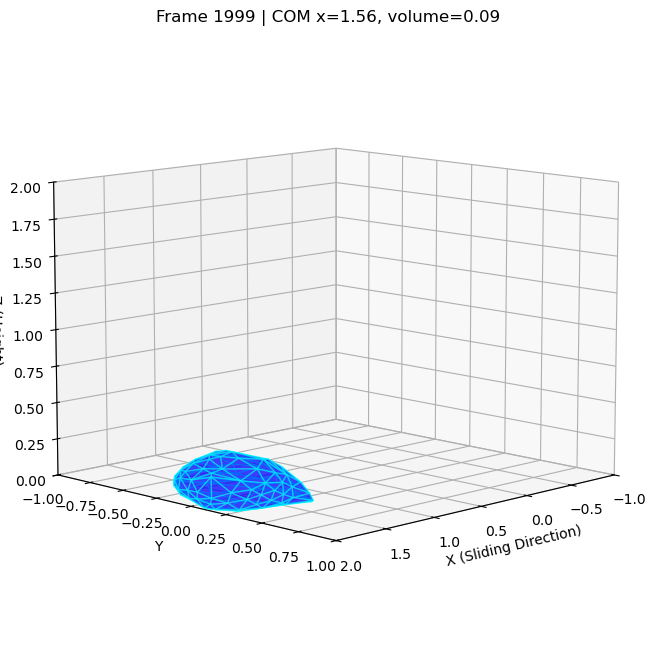

In [33]:
x, faces, neighbours = generate_polyhedron(n_vertices=100, radius=0.3)
v = np.zeros_like(x)
x += np.array([0.0, 0.0, 1.0], dtype=np.float32)  # Drop height
_, V_0 = compute_vertex_normals_and_volume(x, faces)

nu = 0.1  # mapped to eta in the function-based solver

# Simulation settings
dt = 0.008
sub_steps = 8
sub_dt = dt / sub_steps

# Rendering setup
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
poly = Poly3DCollection(x[faces], alpha=0.5, edgecolor="cyan", facecolors="blue")
ax.add_collection3d(poly)
# sc = ax.scatter(x[:, 0], x[:, 1], x[:, 2], c="blue", s=20)

ax.set(
    xlim=(-2, 4),
    ylim=(-3, 3),
    zlim=(0, 4),
    xlabel="X (Sliding Direction)",
    ylabel="Y",
    zlabel="Z (Height)",
    title="Real-Time Interactive Water Droplets Simulator",
)

for frame in range(2000):
    # Explicit internal sub-stepping to maintain simulation stability
    for _ in range(sub_steps):
        v, x = step_simulation(
            v, x, faces, neighbours, V_0,
            dt=sub_dt, 
            g=np.array([4.0, 0.0, -9.81]), # Tilted gravity
            gamma=2000.0,  # higher tension to preserve bead shape
            mu=16.0,        # numerically safer damping than very large explicit mu
            eta=10.0,      # keep Laplacian viscosity in a stable/recommended range
            k_v=2000.0,
            rho=0.1,    # lower density to allow more visible deformation without extreme forces
            alpha=3.0,     # contact angle stiffness
            friction_coeff=0.1,
            damping_gain=1.5, # Apply new robust damping
            receding_angle=np.deg2rad(30.0),
            advancing_angle=np.deg2rad(90.0),
        )
        
        # gamma=50.0, 
        #     mu=3.0, 
        #     eta=0.98, 
        #     k_v=2000.0, 
        #     friction_coeff=0.2,
        

# for frame in range(2000):
#     for _ in range(sub_steps):
#         v, x = step_simulation(
#             v, x, faces, neighbours, V_0,
#             dt=sub_dt, g=np.array([0.0, 0.0, -9.810]),
#             gamma=2000.0,  # higher tension to preserve bead shape
#             mu=16.0,        # numerically safer damping than very large explicit mu
#             eta=8.0,      # keep Laplacian viscosity in a stable/recommended range
#             k_v=2000.0,
#             rho=0.1,    # lower density to allow more visible deformation without extreme forces
#             alpha=3.0,     # contact angle stiffness
#             friction_coeff=0.1,
#             # contact_angles=(np.deg2rad(105.0), np.deg2rad(125.0)),
#             # contact_angles=(np.deg2rad(86.0), np.deg2rad(94.0)),
#             contact_angles=(np.deg2rad(59.0), np.deg2rad(61.0)),
#             volume_correction_mode="both",
#         )
        
        # v, x = step_simulation(
        #     v, x, faces, neighbours, V_0,
        #     dt=sub_dt, g=np.array([0.0, 0.0, -9.810]),
        #     gamma=2000.0,  # higher tension to preserve bead shape
        #     mu=16.0,        # numerically safer damping than very large explicit mu
        #     eta=6.0,      # keep Laplacian viscosity in a stable/recommended range
        #     k_v=2000.0,
        #     rho=0.1,    # lower density to allow more visible deformation without extreme forces
        #     alpha=0.2,     # contact angle stiffness
        #     friction_coeff=0.1,
        #     contact_angles=(np.deg2rad(105.0), np.deg2rad(125.0)),
        #     volume_correction_mode="both",
        # )

    # Update visual data
    # sc._offsets3d = (x[:, 0], x[:, 1], x[:, 2])
    poly.set_verts(x[faces])

    # Keep droplet in view as it slides
    center = x.mean(axis=0)
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1, 1)
    ax.set_zlim(0.0, 2.0)
    _, volume = compute_vertex_normals_and_volume(x, faces)
    ax.set_title(f"Frame {frame} | COM x={center[0]:.2f}, volume={volume:.2f}")
    ax.view_init(elev=10, azim=45)

    # Notebook-friendly refresh
    display.clear_output(wait=True)
    display.display(fig)
    #time.sleep(0.01)

plt.close(fig)